In [12]:
# ### 1. Mount Google Drive ###

from google.colab import drive

drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [19]:
print('Listing contents of your Google Drive to find the dataset zip file...')
!ls -R '/content/gdrive/MyDrive/'

Listing contents of your Google Drive to find the dataset zip file...
/content/gdrive/MyDrive/:
 Alpha-Beta-Pruning-in-Artificial-Intelligence-Optimizing-Decision-Trees.pptx
 CAF_LavBhatia
 Classroom
'Colab Notebooks'
 Course_Completion_CertificateCyber.pdf
 Course_Completion_CertificateThreat.pdf
 covid_dataset.zip
 DOC-20250420-WA0003..pdf
'E aadhar Open .pdf'
'IMG_20250312_175607 (1).jpg'
'IMG_20250312_175607 (2).jpg'
'IMG_20250312_175607 (3).jpg'
 IMG_20250312_175607.jpg
 IMG_20251007_172015.jpg
 IMG_20251129_170138_20251129_170248.jpg
'Lav_Bhatia_Resume (1).pdf'
 Lav_Bhatia_Resume.pdf
 lav_ppt_EOI.pptx
'My Learning _ NVIDIA_Certificate.pdf'
 New
 nRF-Connect-SDK-Fundamentals_nRF-Connect-SDK-Fundamentals_lavbhatia231348@acropolis.in_.pdf
 PDFGallery_20260410_194036.pdf
'receipt  (1).pdf'
'receipt (1).pdf'
'receipt .pdf'
 receipt.pdf
'reciept DBMS .pdf'
'RESULT 4TH SEM .pdf'
 Resume_Lav.gdoc
 Scanned_20250716_192055.pdf
 Screenshot_20250509_150356.jpg
 Screenshot_20251001_112957.jpg

In [20]:
### 2. Prepare data ###

# The original path to 'Brain Tumor YOLO dataset.zip' was not found in your Google Drive.
# I'm modifying this to use 'covid_dataset.zip' which was found in the root of your MyDrive.
# If this is not the intended dataset, please replace the path below with the correct one
# for 'Brain Tumor YOLO dataset.zip' or upload it to your Google Drive.
!scp '/content/gdrive/MyDrive/covid_dataset.zip' '/content/data.zip'

!unzip '/content/data.zip' -d '/content/'

Archive:  /content/data.zip
   creating: /content/covid_dataset/
   creating: /content/covid_dataset/COVID/
  inflating: /content/covid_dataset/COVID/COVID-1.png  
  inflating: /content/covid_dataset/COVID/COVID-10.png  
  inflating: /content/covid_dataset/COVID/COVID-11.png  
  inflating: /content/covid_dataset/COVID/COVID-12.png  
  inflating: /content/covid_dataset/COVID/COVID-13.png  
  inflating: /content/covid_dataset/COVID/COVID-14.png  
  inflating: /content/covid_dataset/COVID/COVID-15.png  
  inflating: /content/covid_dataset/COVID/COVID-16.png  
  inflating: /content/covid_dataset/COVID/COVID-17.png  
  inflating: /content/covid_dataset/COVID/COVID-18.png  
  inflating: /content/covid_dataset/COVID/COVID-19.png  
  inflating: /content/covid_dataset/COVID/COVID-2.png  
  inflating: /content/covid_dataset/COVID/COVID-20.png  
  inflating: /content/covid_dataset/COVID/COVID-21.png  
  inflating: /content/covid_dataset/COVID/COVID-22.png  
  inflating: /content/covid_dataset/COV

In [14]:
### 3. Install packages ###

!git clone https://github.com/autogyro/yolo-V8.git
!cd yolo-V8/ && pip install ultralytics

fatal: destination path 'yolo-V8' already exists and is not an empty directory.


In [21]:
### 4. Prepare YOLO dataset structure and data.yaml ###
import os
import shutil
import random
import yaml

# Define paths
dataset_base_path = '/content/covid_dataset'
yolo_dataset_path = '/content/yolo_covid_dataset'
data_yaml_path = '/content/data.yaml'

# Define class names and their mapping to integer IDs
class_names = ['COVID', 'Normal', 'Viral Pneumonia']
class_mapping = {name: i for i, name in enumerate(class_names)}

# Define splits
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

print(f"Preparing dataset for YOLOv8. Original classes found: {class_names}")
print("Note: Bounding boxes will be generated for the entire image, treating it as a full-frame detection.")

# Create YOLO-compatible directory structure
os.makedirs(os.path.join(yolo_dataset_path, 'images', 'train'), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_path, 'images', 'val'), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_path, 'images', 'test'), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_path, 'labels', 'train'), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_path, 'labels', 'val'), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_path, 'labels', 'test'), exist_ok=True)

all_images = []
for class_folder in class_names:
    class_path = os.path.join(dataset_base_path, class_folder)
    if not os.path.exists(class_path):
        print(f"Warning: Class folder '{class_folder}' not found at '{class_path}'. Skipping.")
        continue
    for img_name in os.listdir(class_path):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_images.append((os.path.join(class_path, img_name), class_mapping[class_folder]))

# Shuffle and split images
random.shuffle(all_images)
num_images = len(all_images)
num_train = int(num_images * train_ratio)
num_val = int(num_images * val_ratio)
num_test = num_images - num_train - num_val # Ensure all images are used

train_images = all_images[:num_train]
val_images = all_images[num_train : num_train + num_val]
test_images = all_images[num_train + num_val :]

splits = {
    'train': train_images,
    'val': val_images,
    'test': test_images
}

# Copy images and create label files
for split_name, image_list in splits.items():
    print(f"Processing {split_name} split with {len(image_list)} images...")
    for img_src_path, class_id in image_list:
        img_filename = os.path.basename(img_src_path)
        # Construct destination path for image
        img_dest_path = os.path.join(yolo_dataset_path, 'images', split_name, img_filename)
        shutil.copy(img_src_path, img_dest_path)

        # Construct destination path for label file
        label_filename = os.path.splitext(img_filename)[0] + '.txt'
        label_dest_path = os.path.join(yolo_dataset_path, 'labels', split_name, label_filename)

        # Create YOLO format label: class_id center_x center_y width height
        # Assuming the object fills the entire image (for classification-like detection)
        with open(label_dest_path, 'w') as f:
            f.write(f"{class_id} 0.5 0.5 1.0 1.0\n")

print("Dataset preparation complete.")

# Generate data.yaml file
data_yaml_content = {
    'path': yolo_dataset_path, # Dataset root directory
    'train': 'images/train',   # Relative path to train images from 'path'
    'val': 'images/val',       # Relative path to val images from 'path'
    'test': 'images/test',     # Relative path to test images from 'path' (optional)
    'nc': len(class_names),    # Number of classes
    'names': class_names       # Class names
}

with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, sort_keys=False)

print(f"'{data_yaml_path}' created successfully:")
with open(data_yaml_path, 'r') as f:
    print(f.read())

Preparing dataset for YOLOv8. Original classes found: ['COVID', 'Normal', 'Viral Pneumonia']
Note: Bounding boxes will be generated for the entire image, treating it as a full-frame detection.
Processing train split with 120 images...
Processing val split with 15 images...
Processing test split with 15 images...
Dataset preparation complete.
'/content/data.yaml' created successfully:
path: /content/yolo_covid_dataset
train: images/train
val: images/val
test: images/test
nc: 3
names:
- COVID
- Normal
- Viral Pneumonia



In [22]:
### 4. Train model ###

import os

from ultralytics import YOLO


config_path = '/content/data.yaml'


!yolo task=detect mode=train model=yolov8n.pt data={config_path} epochs=50 imgsz=640 plots=True

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

In [23]:
# ------------------ Fix for Encoding Issues ------------------
# Sometimes, especially on platforms like Google Colab or Windows,
# you might face locale/encoding issues when running external commands.
# So, you override 'getpreferredencoding' to always return 'UTF-8'.

import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"

# Patch the 'locale' module's getpreferredencoding method
locale.getpreferredencoding = getpreferredencoding

# ------------------ Run YOLOv8 Validation ------------------
# This command runs validation (evaluation) of a trained YOLO model.

!yolo task=detect mode=val model=runs/detect/train-3/weights/best.pt data=/content/data.yaml save_json=True

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1113.3±227.5 MB/s, size: 35.7 KB)
val: Scanning /content/yolo_covid_dataset/labels/val.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 2.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.5it/s 0.4s
                   all         15         15      0.886      0.958      0.941      0.941
                 COVID          8          8      0.987      0.875      0.982      0.982
                Normal          4          4      0.745          1      0.845      0.845
       Viral Pneumonia          3          3      0.924          1      0.995      0.995
Speed: 1.0ms preprocess, 5.7ms inference, 0.0ms loss, 1.4ms postprocess per image
Saving /content/runs/detect/val/predictions.json...
R

Using image for single prediction: /content/yolo_covid_dataset/images/test/Viral Pneumonia-49.png
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 /content/yolo_covid_dataset/images/test/Viral Pneumonia-49.png: 640x640 1 Viral Pneumonia, 8.8ms
Speed: 3.8ms preprocess, 8.8ms inference, 15.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/single_image_predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


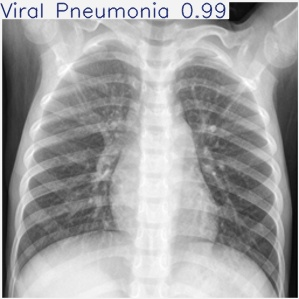

In [26]:
from IPython.display import Image, display
import glob
import os

# Define the path to the test images created earlier
test_images_dir = '/content/yolo_covid_dataset/images/test'

# Get a list of all image files in the test directory
available_test_images = [os.path.join(test_images_dir, f) for f in os.listdir(test_images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Select the first image from the list for prediction, if available
if available_test_images:
    single_image_to_predict = available_test_images[0]
    print(f"Using image for single prediction: {single_image_to_predict}")

    !yolo predict model=/content/runs/detect/train-3/weights/best.pt \
                  source="{single_image_to_predict}" \
                  project=/content/runs/detect \
                  name=single_image_predict \
                  exist_ok=True

    # Find the path of the predicted image (YOLOv8 saves output in 'runs/detect/single_image_predict' by default)
    predicted_images = glob.glob('/content/runs/detect/single_image_predict/*.jpg') # or .png if needed

    # Display the first predicted image
    if predicted_images:
        display(Image(filename=predicted_images[0]))
    else:
        print("No predicted images found for single_image_predict.")
else:
    print(f"No images found in {test_images_dir} to perform a single image prediction.")


image 1/1 /content/yolo_covid_dataset/images/test/Viral Pneumonia-49.png: 640x640 1 Viral Pneumonia, 11.1ms
Speed: 7.3ms preprocess, 11.1ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predictions
15 labels saved to /content/runs/detect/predictions/labels

image 1/1 /content/yolo_covid_dataset/images/test/Viral Pneumonia-44.png: 640x640 1 Viral Pneumonia, 7.3ms
Speed: 3.1ms preprocess, 7.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predictions
15 labels saved to /content/runs/detect/predictions/labels

image 1/1 /content/yolo_covid_dataset/images/test/Viral Pneumonia-7.png: 640x640 1 Viral Pneumonia, 8.9ms
Speed: 3.2ms preprocess, 8.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predictions
15 labels saved to /content/runs/detect/predictions/labels

image 1/1 /content/yolo_covid_dataset/images/test/Normal-42

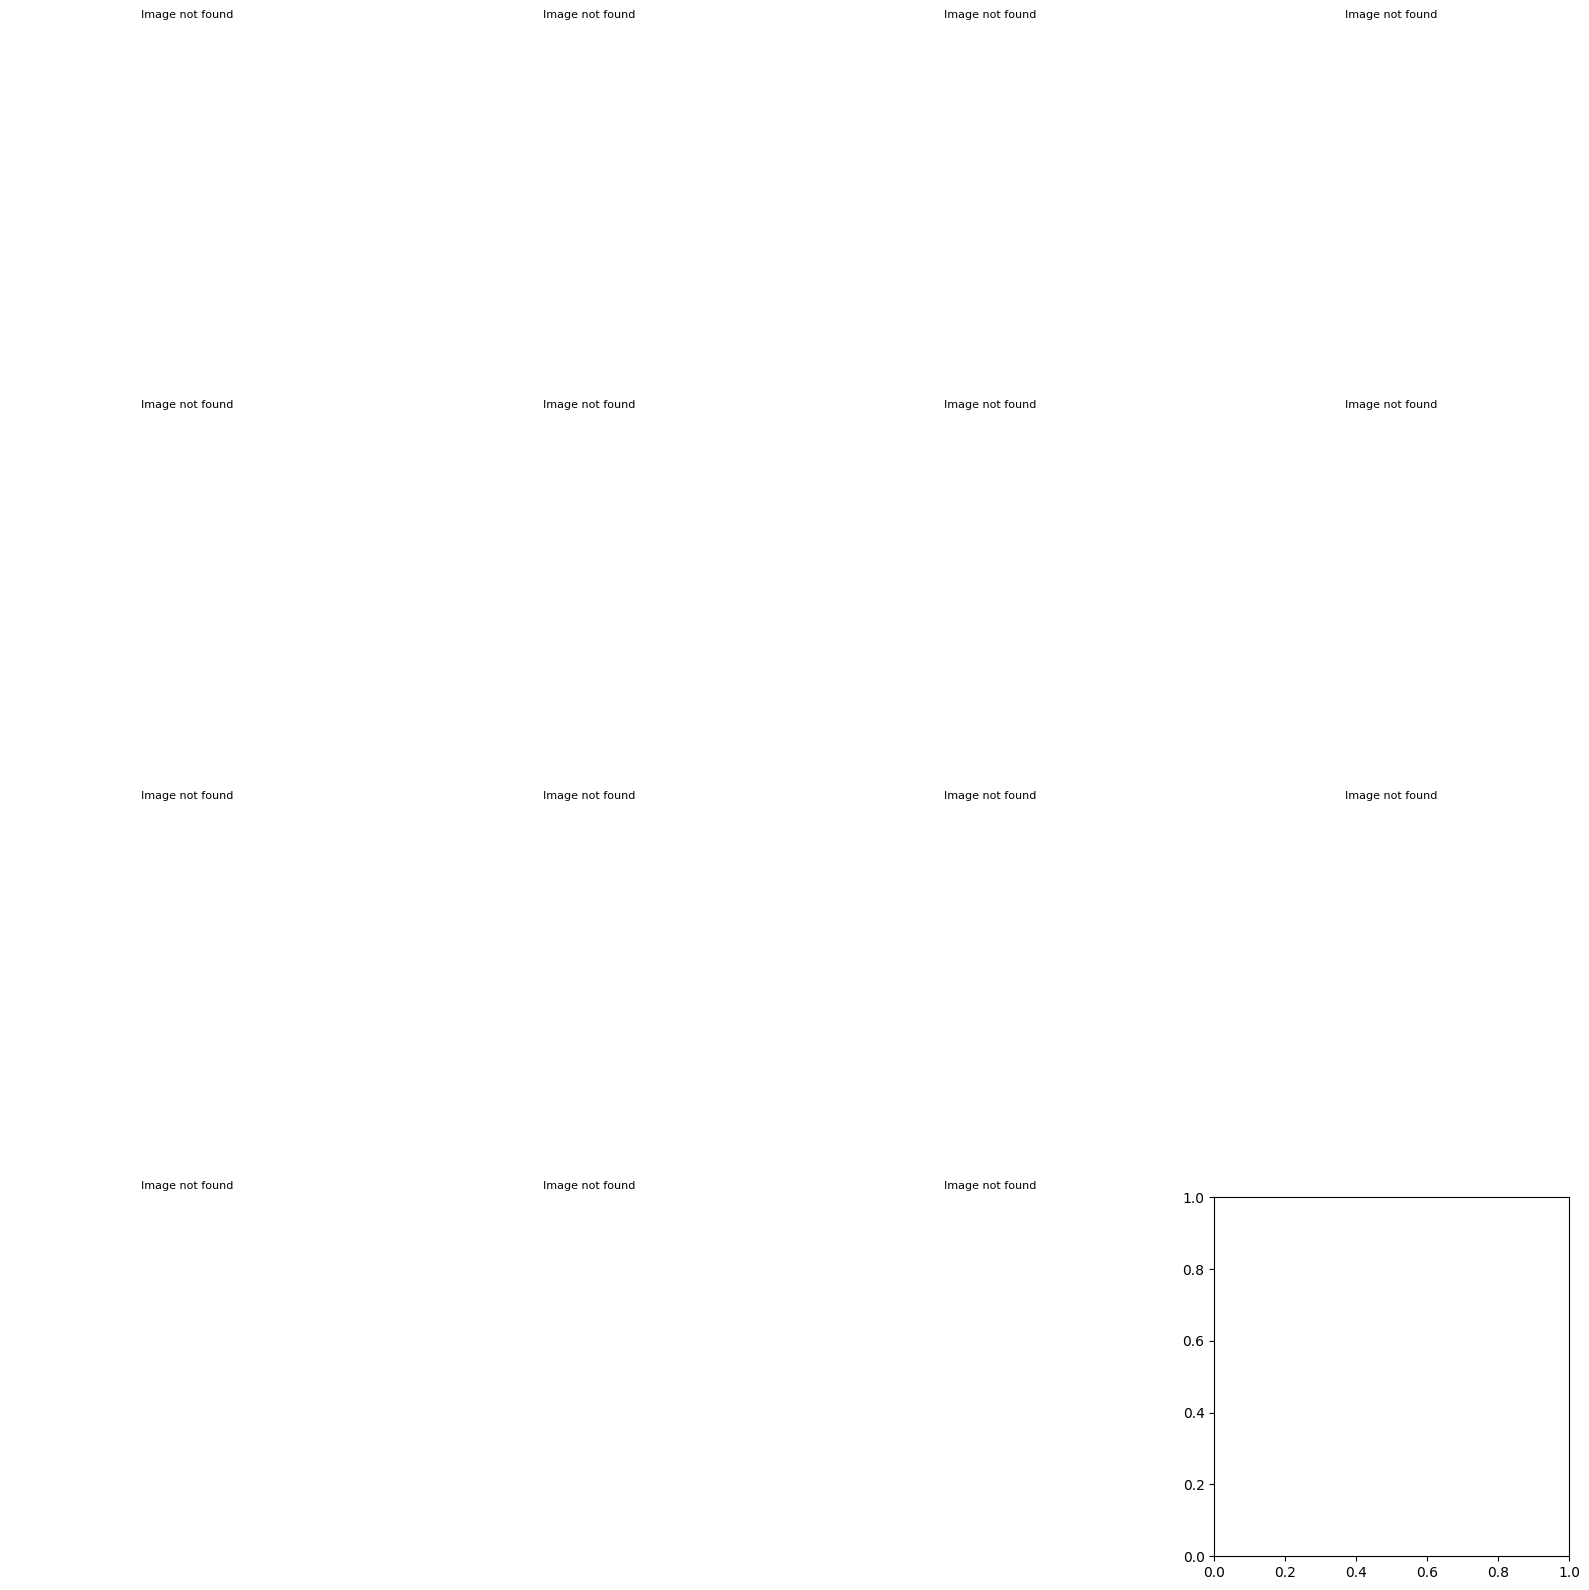

In [27]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Paths
test_folder = '/content/yolo_covid_dataset/images/test' # Changed to use the generated test set
output_folder = '/content/runs/detect'
output_name = 'predictions'
output_path = os.path.join(output_folder, output_name)

# Ensure output directory exists
os.makedirs(output_path, exist_ok=True)

# Load model
model = YOLO('/content/runs/detect/train-3/weights/best.pt')

# Select up to 16 test images
test_images = [os.path.join(test_folder, img) for img in os.listdir(test_folder) if img.endswith(('.jpg', '.png'))][:16]

# Run predictions and save
results = []
for img_path in test_images:
    result = model.predict(source=img_path, save=True, save_txt=True, project=output_folder, name=output_name, exist_ok=True)
    results.append(result)

# Gather predicted image paths
predicted_images = [os.path.join(output_path, os.path.basename(img_path)) for img_path in test_images]

# Display images in 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, img_path in enumerate(predicted_images):
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(os.path.basename(img_path), fontsize=8)
        axes[i].axis('off')
    else:
        axes[i].axis('off')
        axes[i].set_title("Image not found", fontsize=8)

plt.tight_layout()
plt.show()

In [28]:
### 5. Download results ###

from google.colab import files


!zip -r /content/runs.zip /content/runs

files.download('/content/runs.zip')

  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/train-3/ (stored 0%)
  adding: content/runs/detect/train-3/confusion_matrix_normalized.png (deflated 28%)
  adding: content/runs/detect/train-3/val_batch0_pred.jpg (deflated 16%)
  adding: content/runs/detect/train-3/train_batch2.jpg (deflated 10%)
  adding: content/runs/detect/train-3/train_batch320.jpg (deflated 18%)
  adding: content/runs/detect/train-3/BoxP_curve.png (deflated 12%)
  adding: content/runs/detect/train-3/train_batch1.jpg (deflated 12%)
  adding: content/runs/detect/train-3/weights/ (stored 0%)
  adding: content/runs/detect/train-3/weights/best.pt (deflated 9%)
  adding: content/runs/detect/train-3/weights/last.pt (deflated 9%)
  adding: content/runs/detect/train-3/train_batch0.jpg (deflated 10%)
  adding: content/runs/detect/train-3/results.png (deflated 6%)
  adding: content/runs/detect/train-3/BoxR_curve.png (deflated 16%)
  adding: content/runs/detect/train

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>